In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os, sys

In [4]:
os.listdir()

['fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npy',
 'validate_FR.ipynb',
 'fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npz']

In [5]:
fr_new = np.load('fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npy').reshape(25,25,6399)[:,:,:2000]*1000
fr_old = np.load('fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npz')['response']
response_npz = np.load('/home/rrazakami/work/ND-LAr/data_tred/responses/response_44_v2a_full.npz')['response']

In [6]:
fr_new.shape, fr_old.shape, response_npz.shape

((25, 25, 2000), (25, 25, 2000), (45, 45, 3900))

In [9]:
shift = np.argmax(response_npz[0,0]) - np.argmax(fr_new[0,0])
print(f'shift : {shift}')

shift : 2086


In [16]:
def plot_fr(fr_new, fr_old, N=5, k=0, shift=0):
    plt.subplots(N-k,N-k, figsize=(20,20))
    for i in range(k, N):
        for j in range(k, N):
            plt.subplot(N-k,N-k,(i-k)*(N-k)+j-k+1)
            plt.plot(np.arange(fr_new.shape[2]), fr_new[i,j], label=f'new {i},{j}')
            plt.plot(np.arange(fr_old.shape[2])-shift, fr_old[i,j], label=f'official {i},{j}')
            plt.xlim(1000, 2000)
            plt.legend()
    plt.tight_layout()
    plt.show()

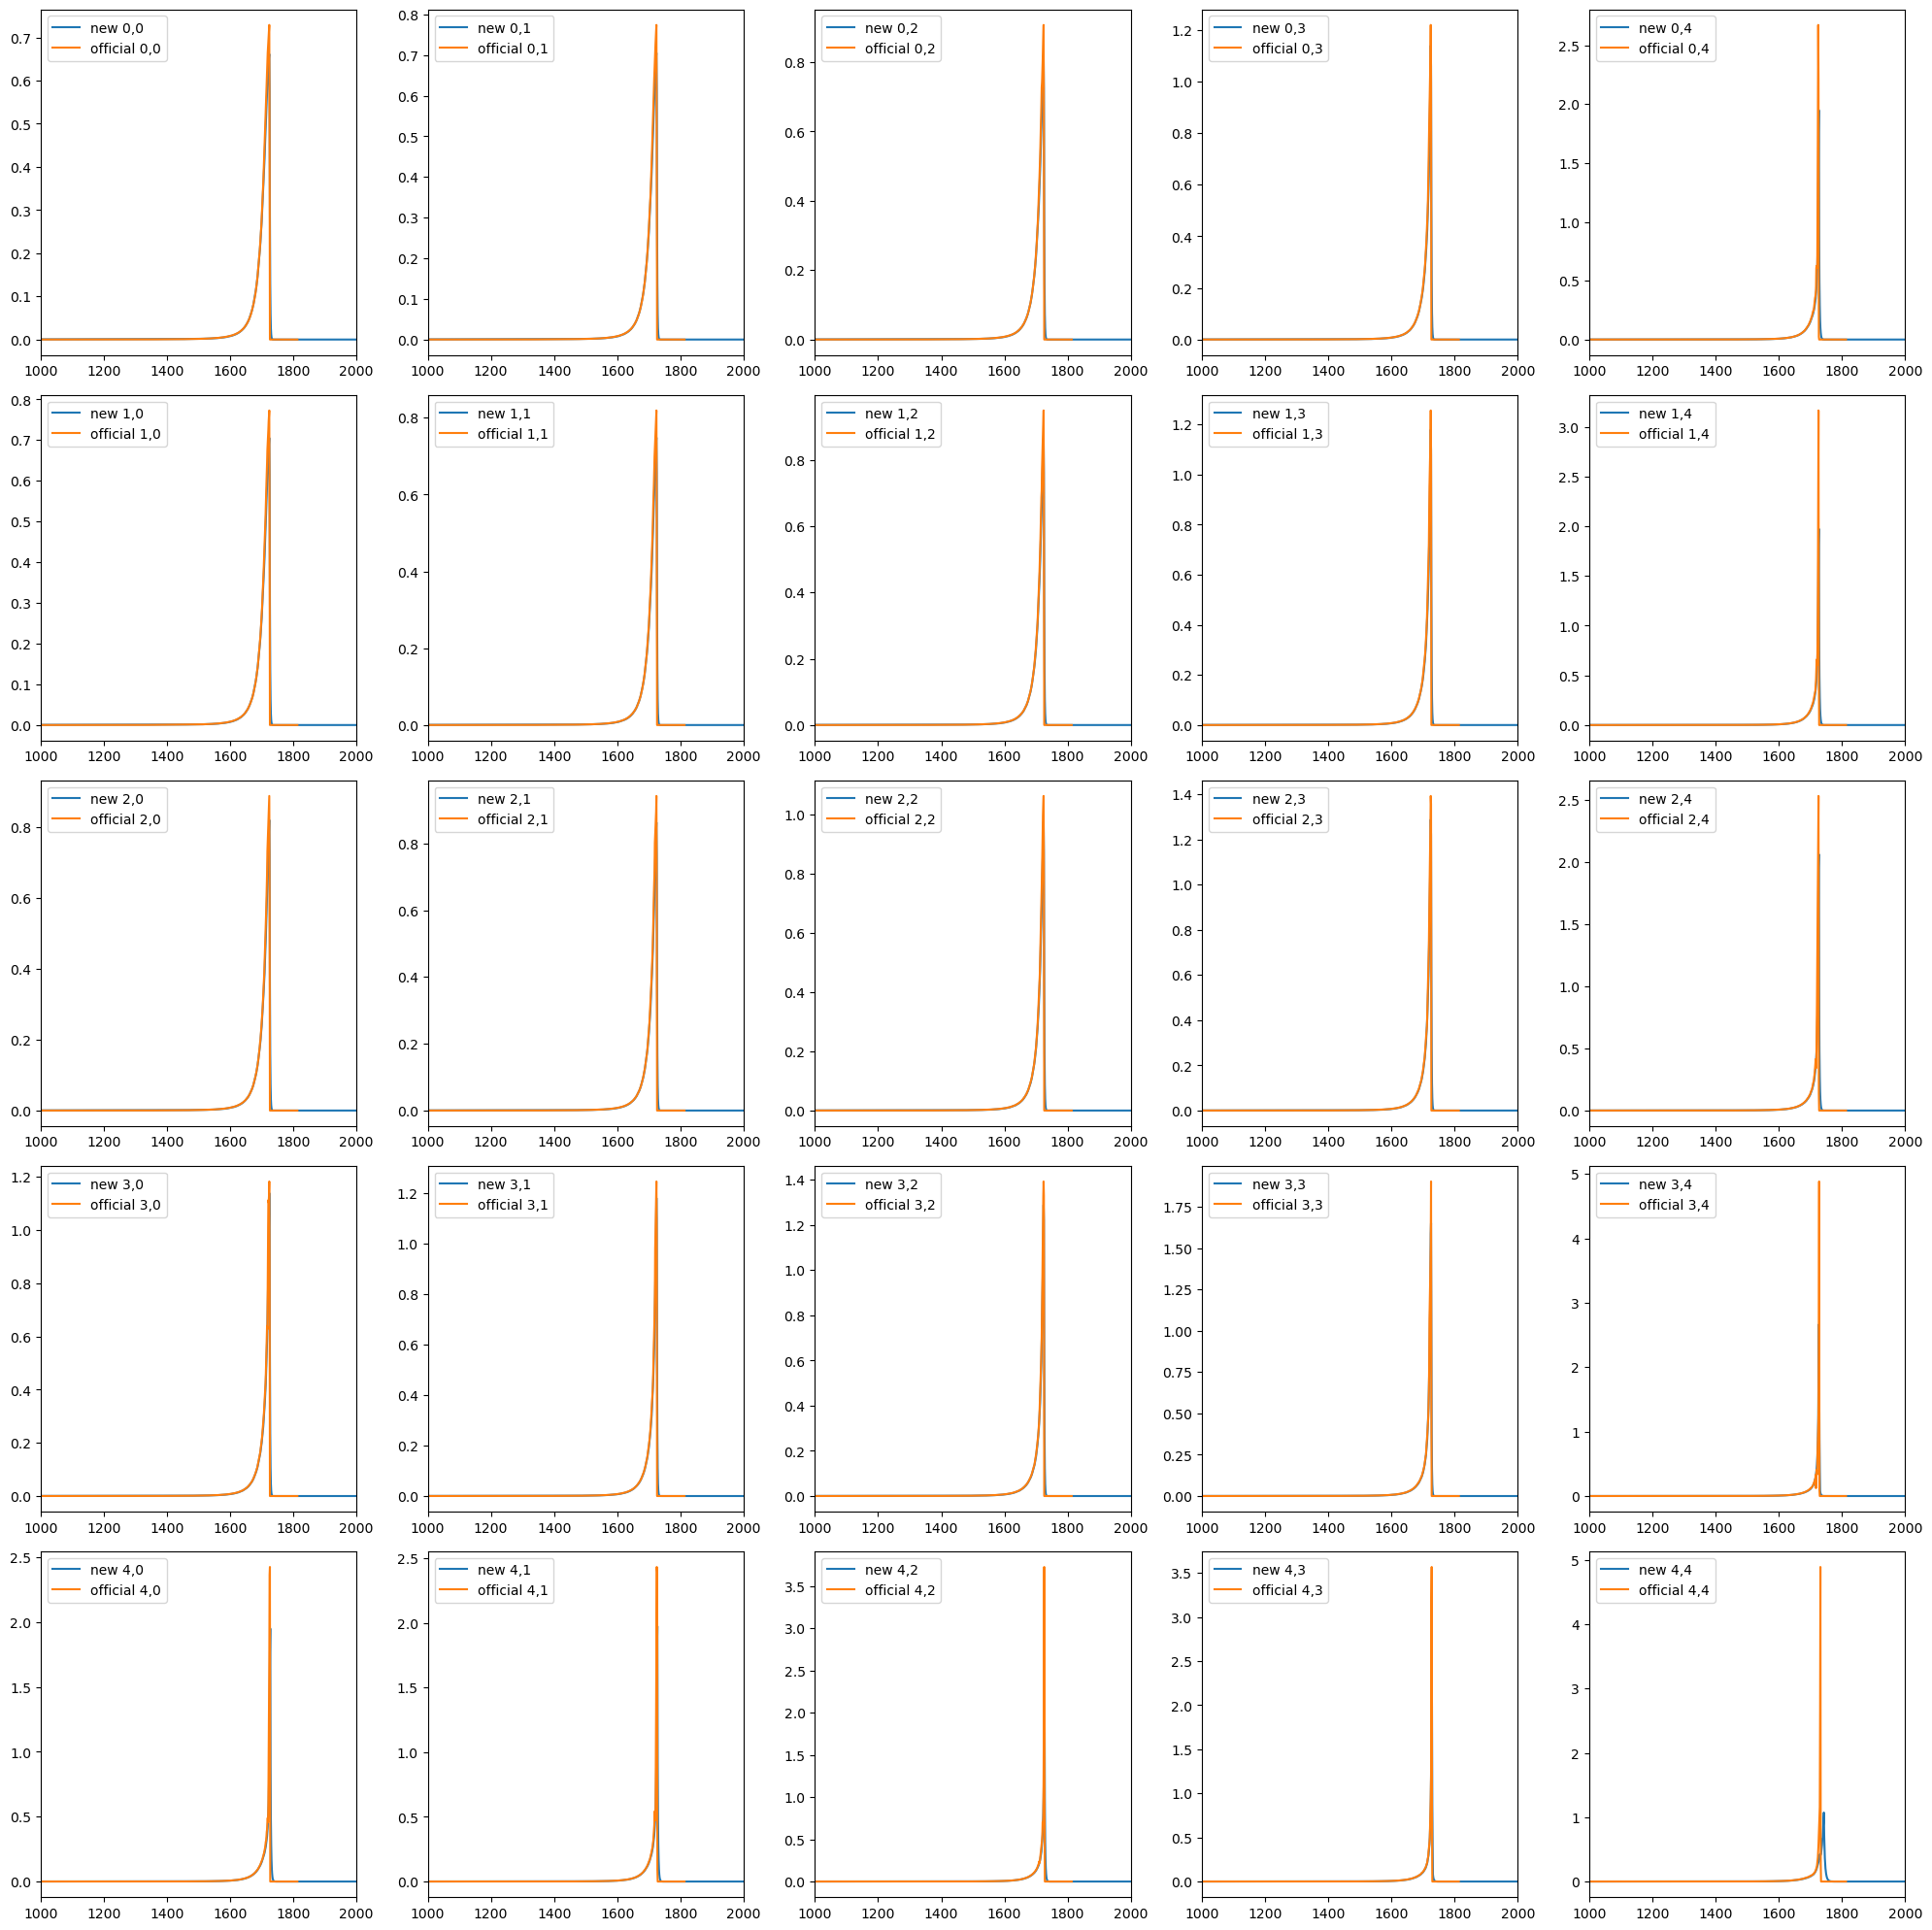

In [17]:
plot_fr(fr_new, response_npz, 5, 0, shift)

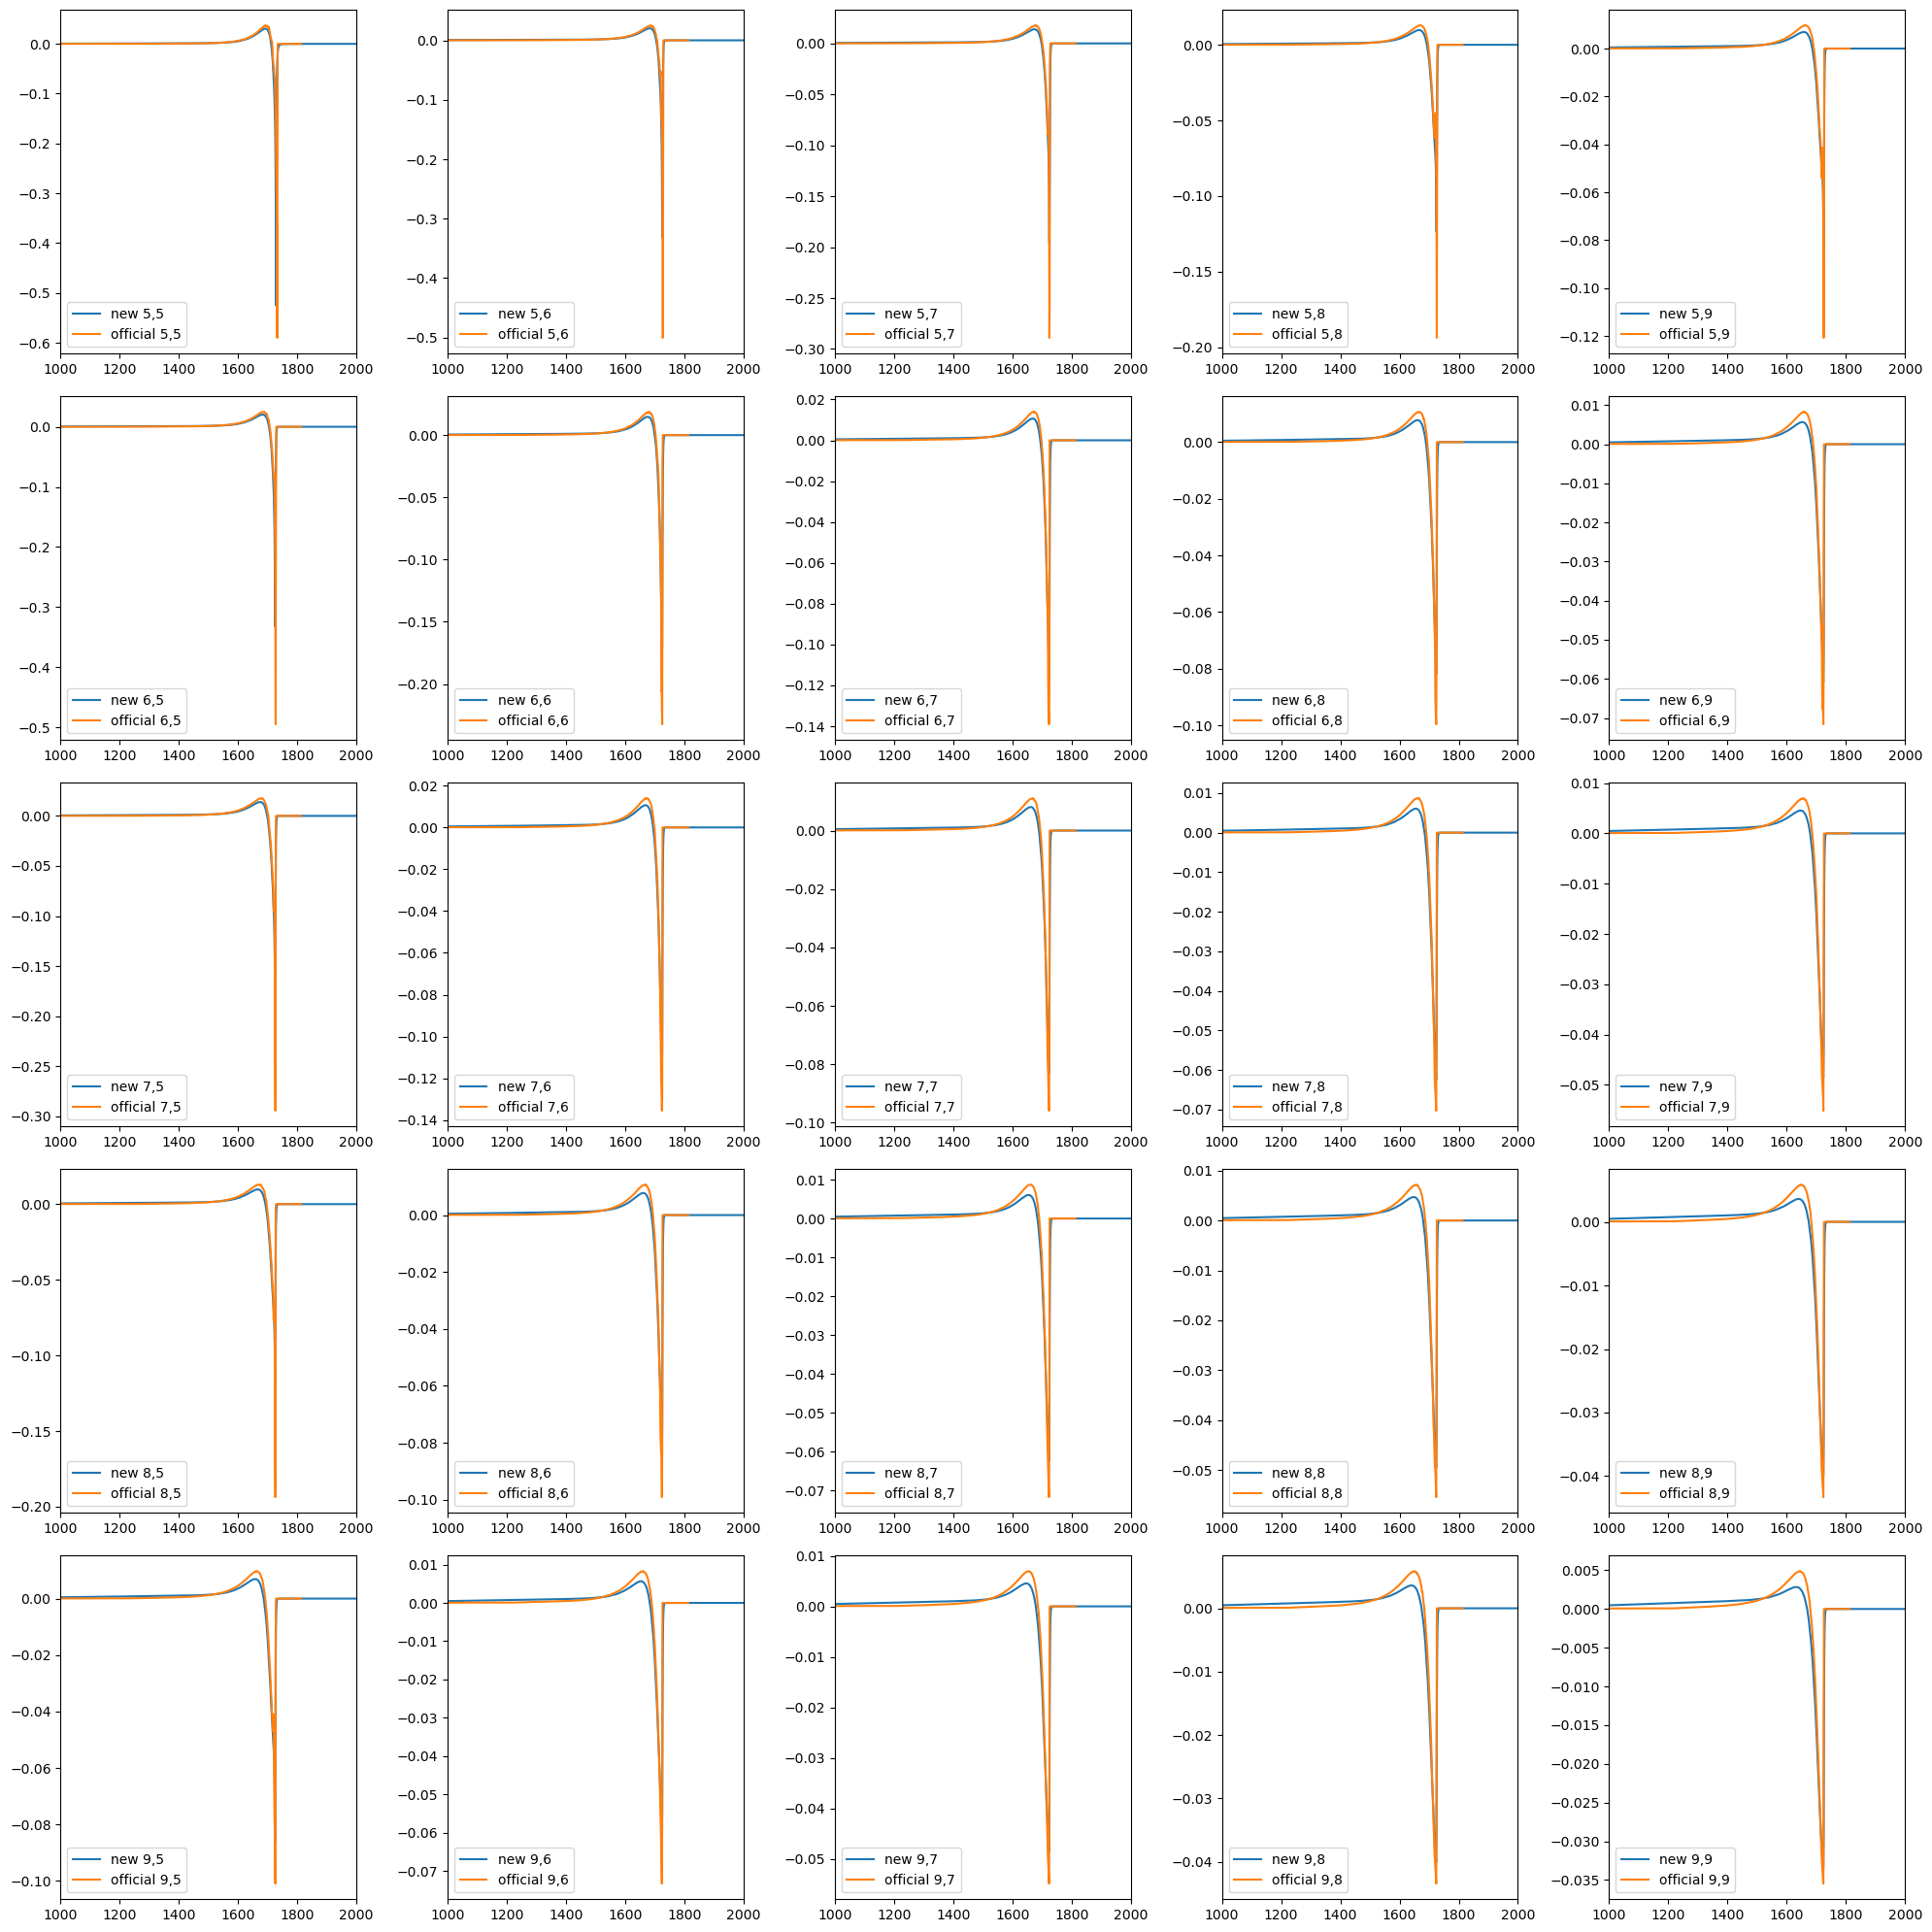

In [18]:
plot_fr(fr_new, response_npz, 10, 5, shift)

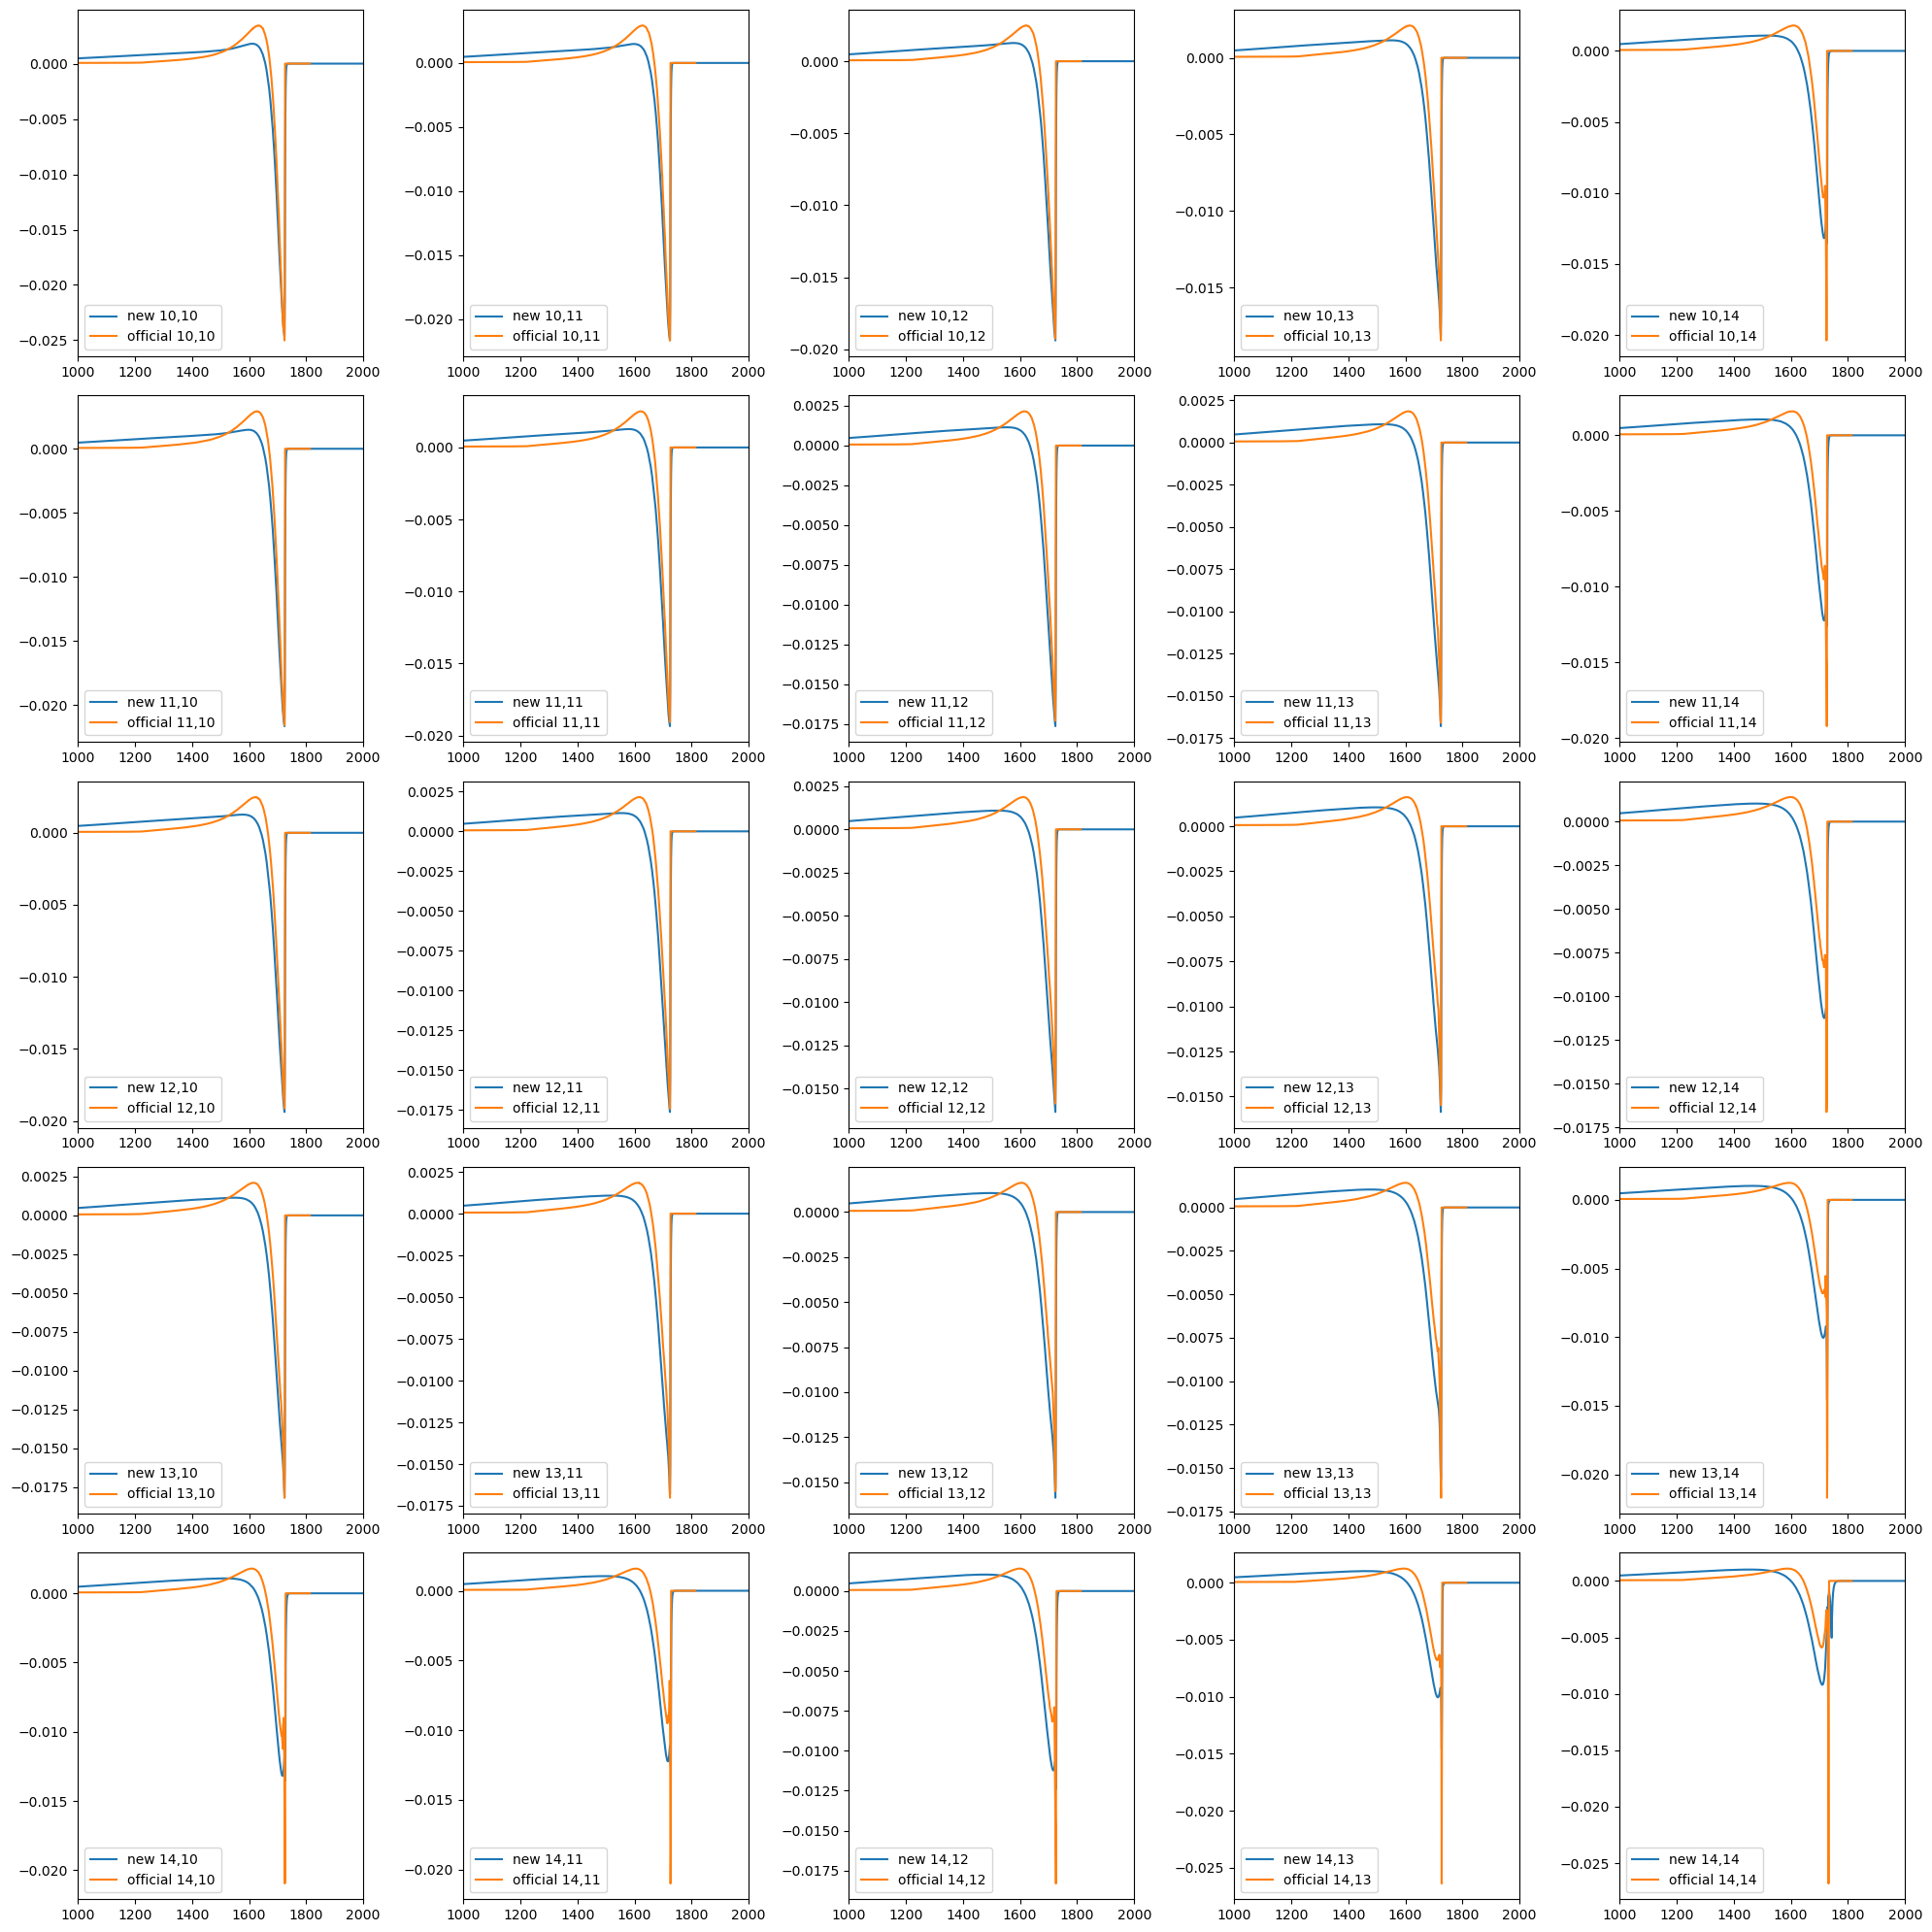

In [19]:
plot_fr(fr_new, response_npz, 15, 10, shift)

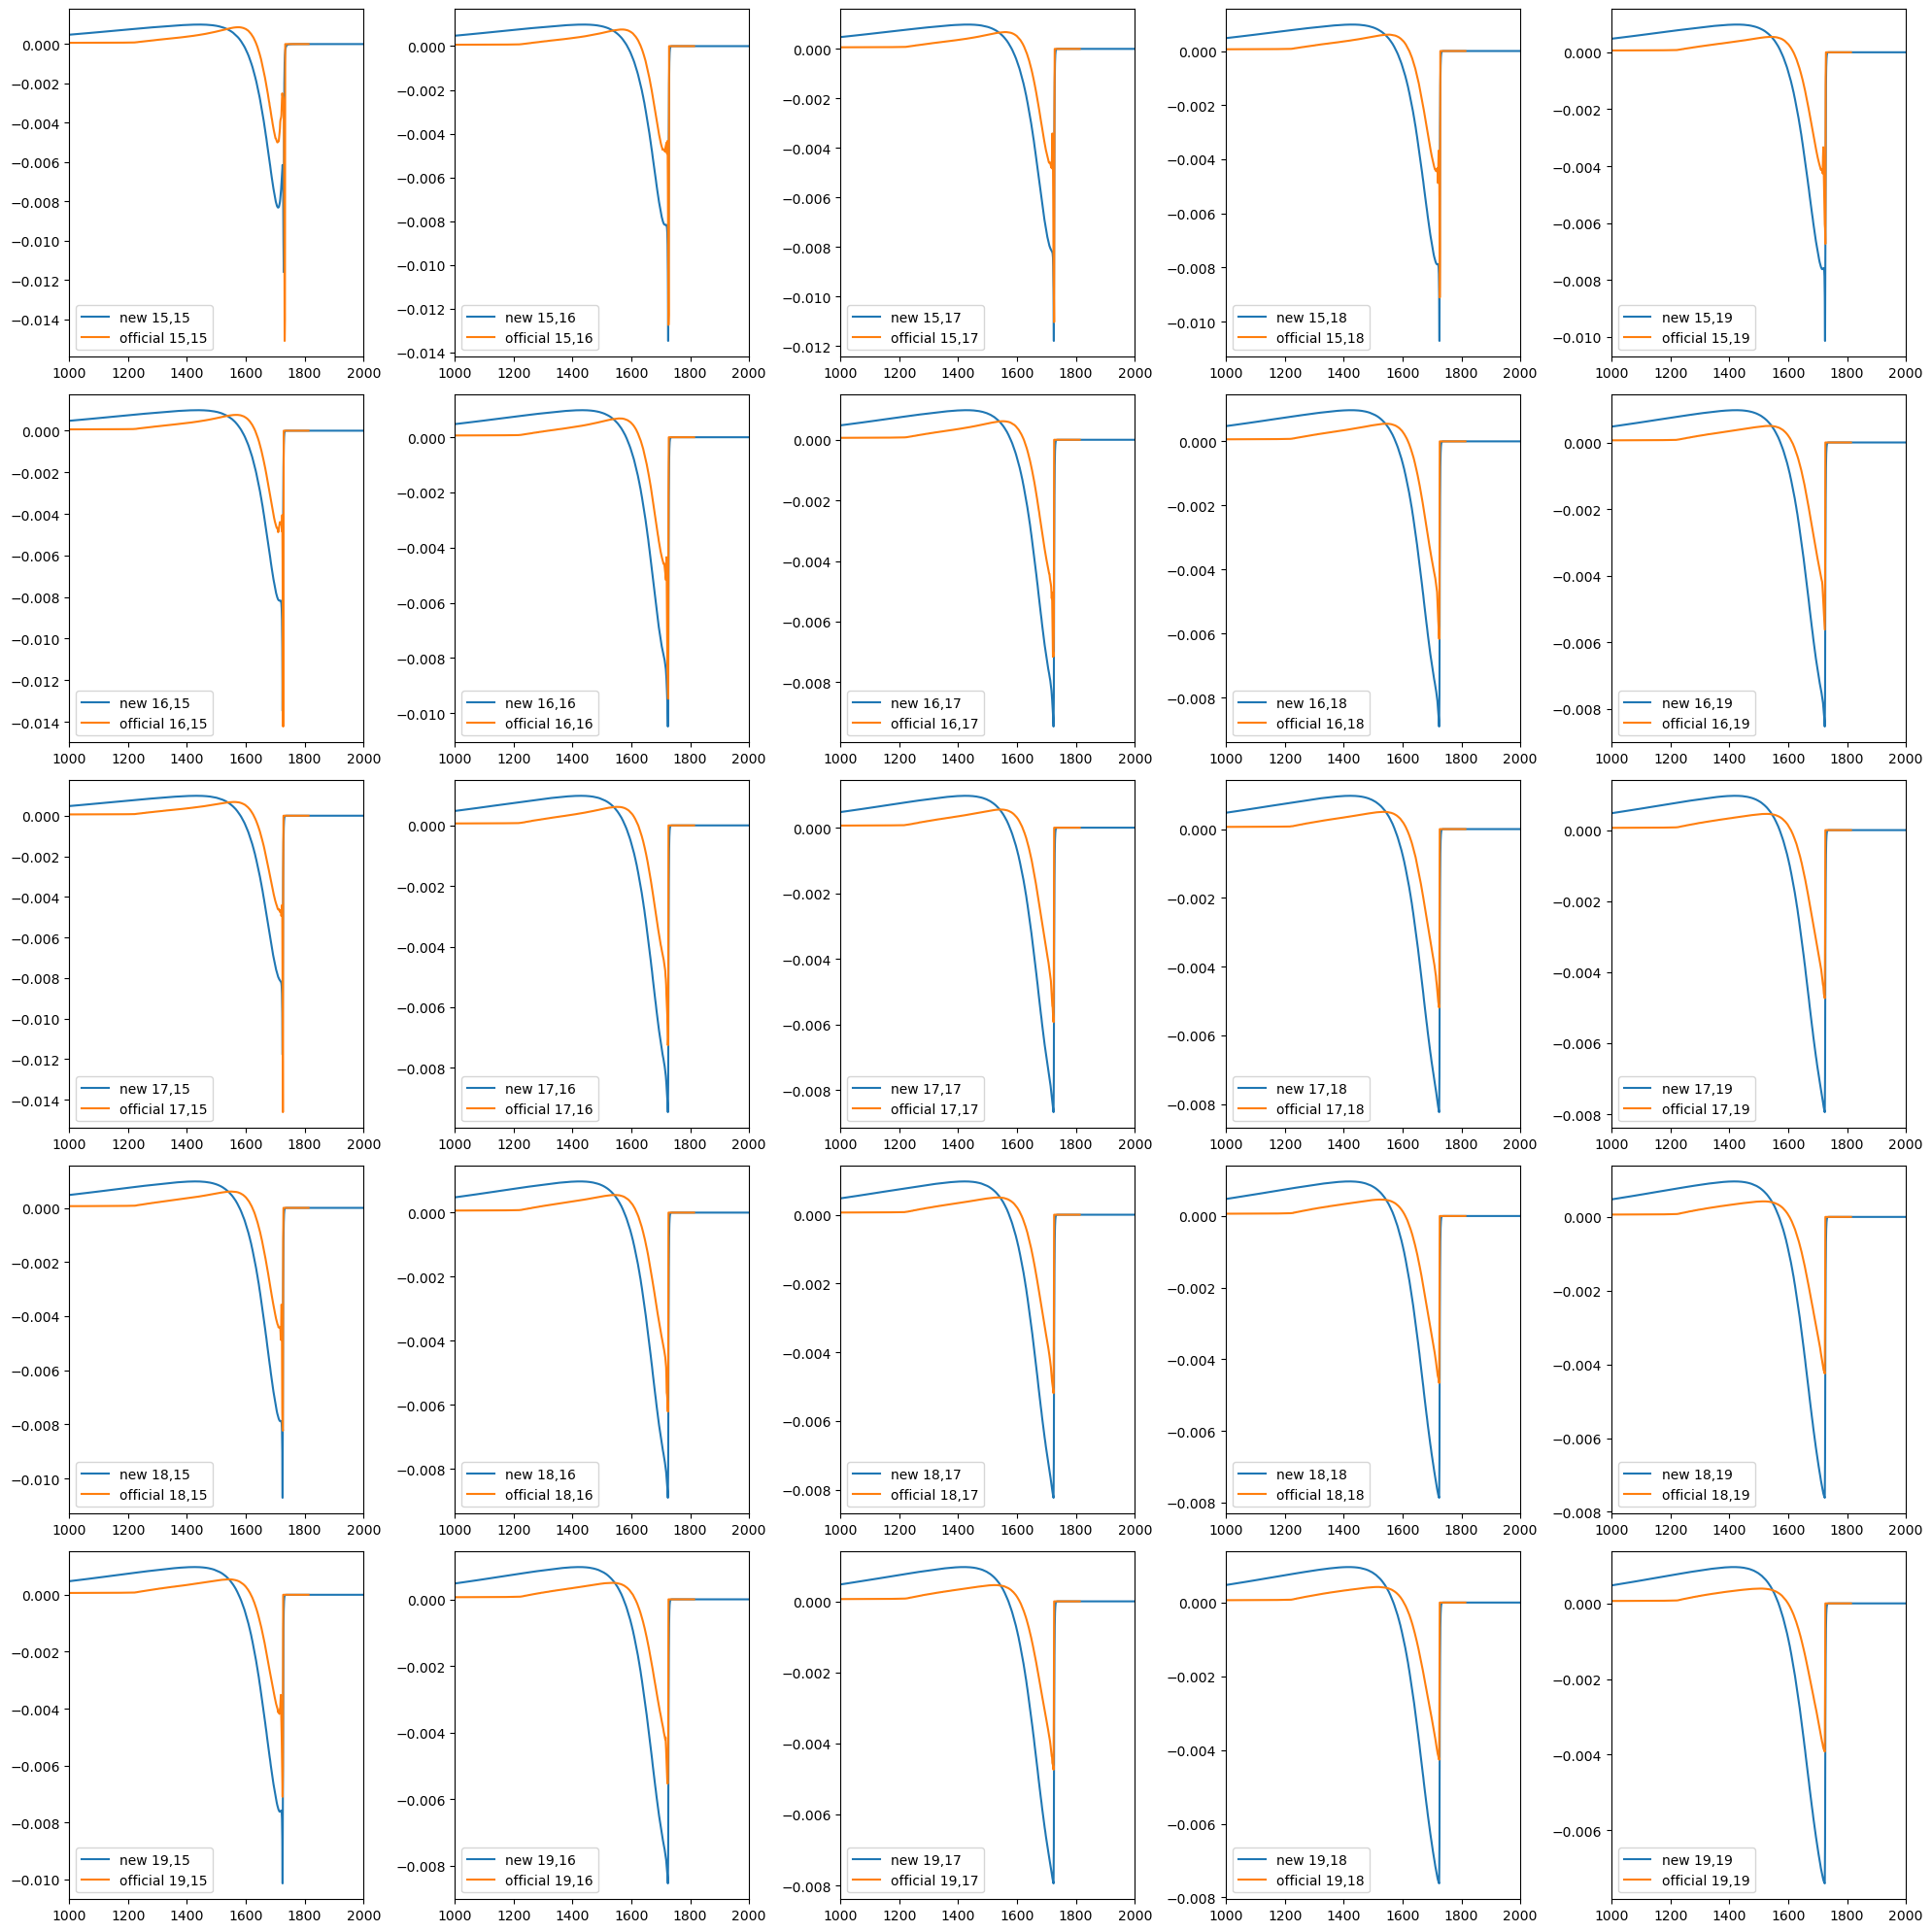

In [20]:
plot_fr(fr_new, response_npz, 20, 15, shift)

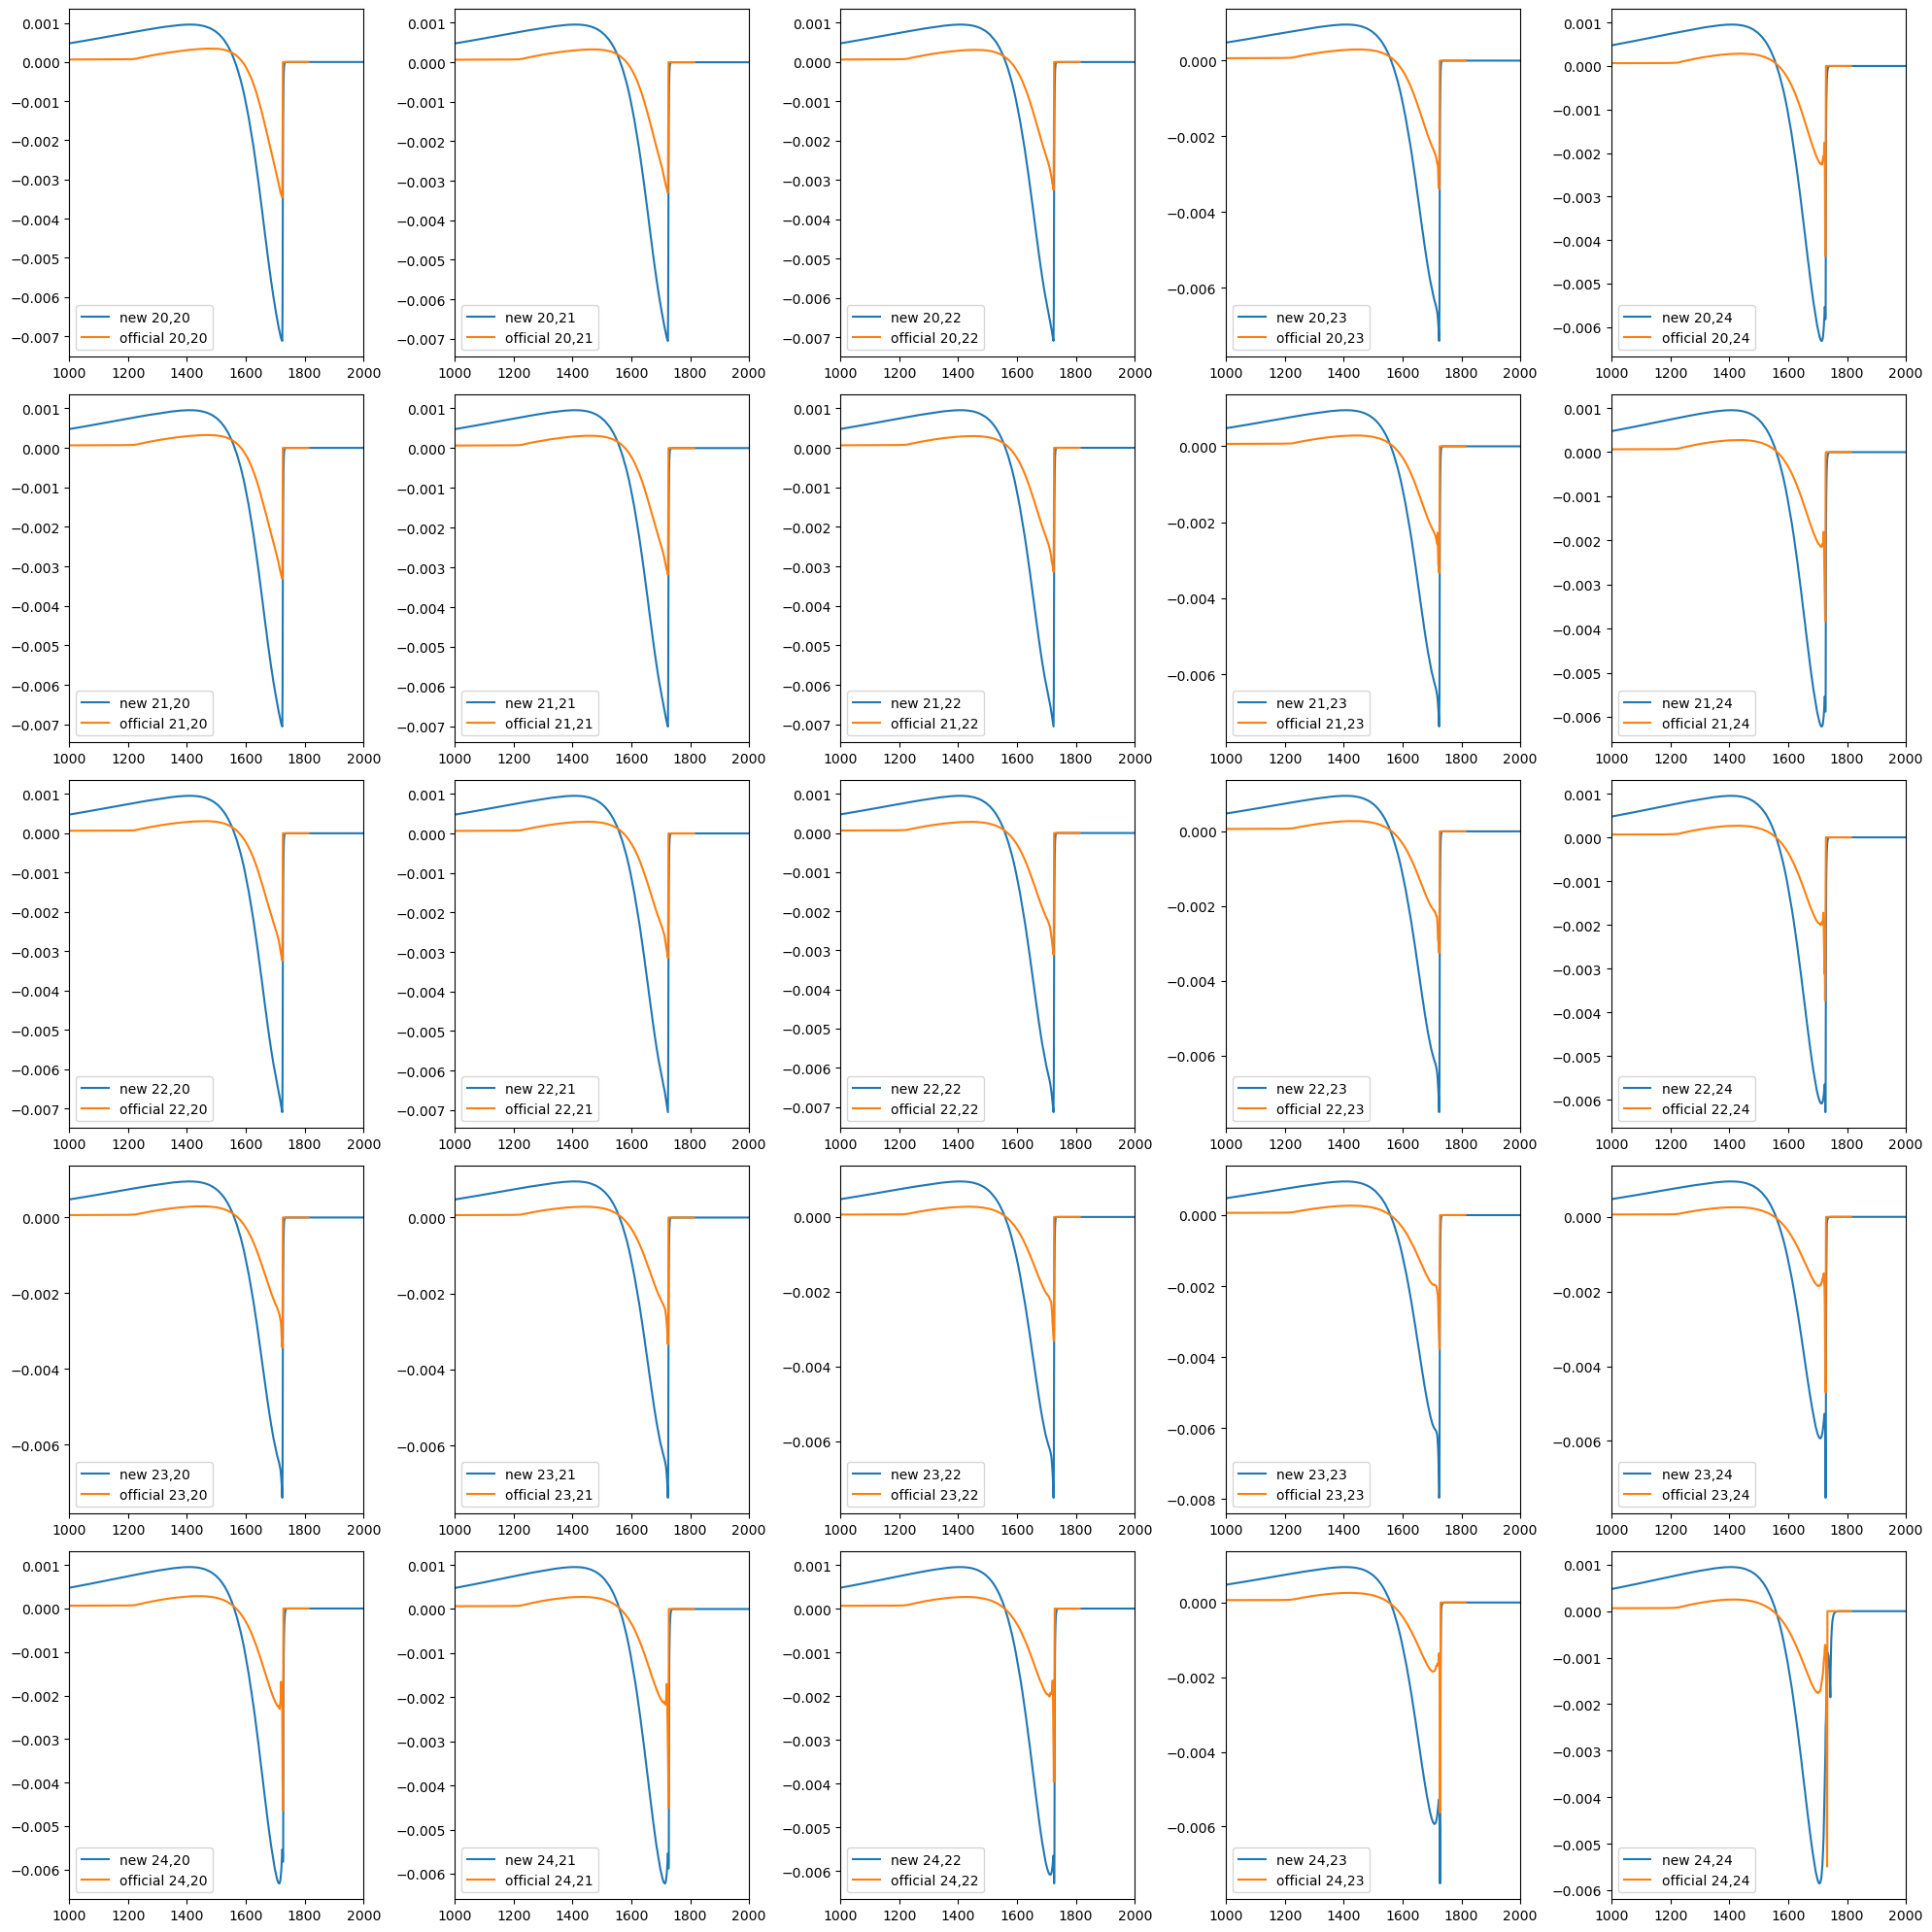

In [21]:
plot_fr(fr_new, response_npz, 25, 20, shift)